In [101]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, rc,colors
import os
from salishsea_tools import visualisations as vis
import netCDF4 as nc

In [102]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [103]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [104]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])

In [105]:
path_run = '/data/jvalenti/results/' 
start = datetime(2024,1,1)

hbac_winter = xr.open_dataset(path_run+make_filename(path_run,start,0, var='biol_T', res='h')).heterotrophic_bacteria.isel(time_counter=0)
hbac_spring = xr.open_dataset(path_run+make_filename(path_run,start,115, var='biol_T', res='h')).heterotrophic_bacteria.isel(time_counter=0)
hbac_summer = xr.open_dataset(path_run+make_filename(path_run,start,200, var='biol_T', res='h')).heterotrophic_bacteria.isel(time_counter=0)

In [106]:
#(imin,imax,jmin,jmax)
regions = {'JdF':(25,125,250,400),'NSoG':(100,225,650,720),'CSoG':(180,300,450,550),'PS':(200,300,25,200)}
colors_reg={'JdF':'tab:blue','NSoG':'tab:orange','CSoG':'tab:green','PS':'tab:red'}
def mark_region(axs,region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    axs.plot(x, y, color=color,label=region)

In [107]:
thalweg_file = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'
thalweg_file2 = '/home/jvalenti/MOAD/analysis-jose/notebooks/Outfall_finalResults/mythalweg6.txt'

thalweg_pts = np.loadtxt(thalweg_file, delimiter=' ', dtype=int)
thalweg_pts2 = np.loadtxt(thalweg_file2, delimiter=' ', dtype=int)

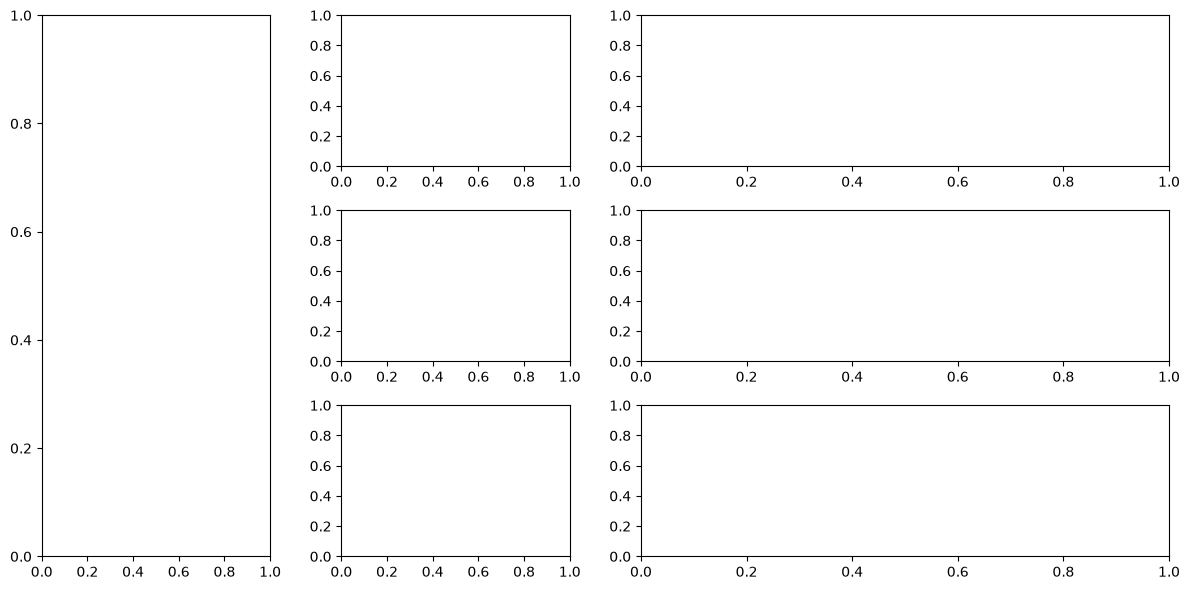

In [108]:
import matplotlib.gridspec as gridspec
cmap = 'RdPu'
colorsn=['tab:blue','tab:orange','tab:green','tab:red']

# Create a figure and a GridSpec layout
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(3, 4, height_ratios=[1, 1, 1], width_ratios=[1, 1,1,1])

# Add the first two single large figures (one per column)
ax1 = fig.add_subplot(gs[:, 0])  # Occupies all rows in column 1

# Add the upper thalweg
ax2 = fig.add_subplot(gs[0, 1])  # PS
ax3 = fig.add_subplot(gs[0, 2:])  # JdF & SoG

# Add the middle thalweg
ax4 = fig.add_subplot(gs[1, 1])  # PS
ax5 = fig.add_subplot(gs[1, 2:])  # JdF & SoG

# Add the bottom thalweg
ax6 = fig.add_subplot(gs[2, 1])  # PS
ax7 = fig.add_subplot(gs[2, 2:])  # JdF & SoG

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
axes = fig.get_axes()

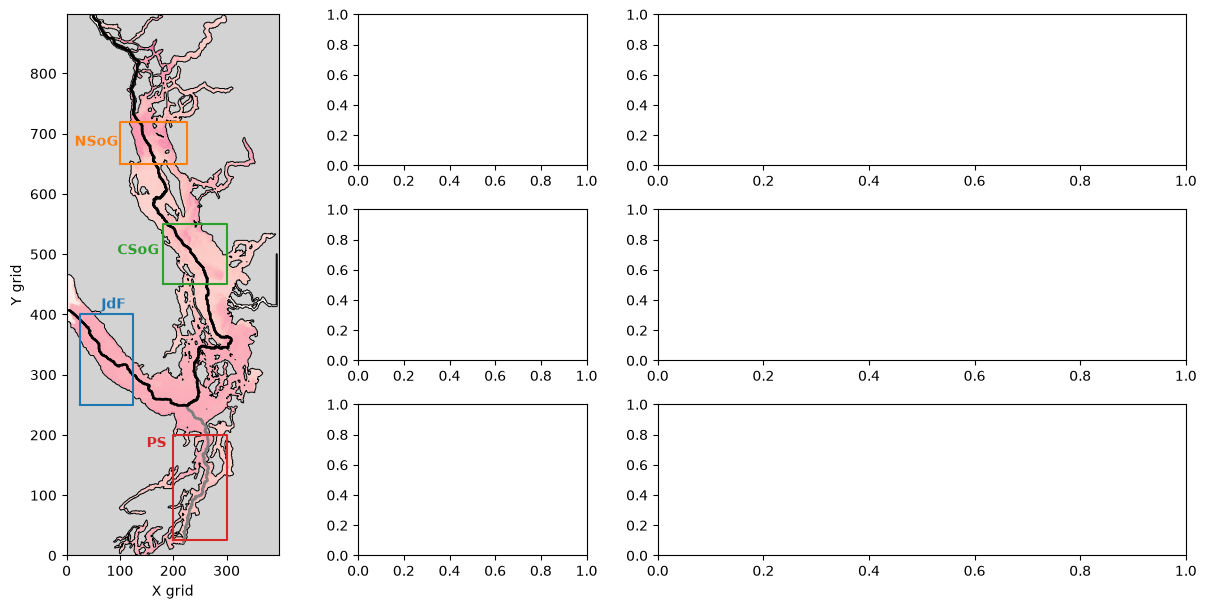

In [109]:
axes[0].clear()
vmax = 0.8

im_map = axes[0].pcolormesh(hbac_spring[0,:,:],cmap=cmap,vmax=vmax)
axes[0].contourf(mask.x, mask.y, mask.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='lightgray')
axes[0].contour(mask.x, mask.y, mask.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='k',linewidth =0.7)
axes[0].plot(thalweg_pts2[:,1]+1,thalweg_pts2[:,0]+1,marker='o',color='grey',markersize=0.25)
axes[0].plot(thalweg_pts[:,1]+1,thalweg_pts[:,0]+1,marker='o',color='k',markersize=0.25)
axes[0].set_aspect(1.13)
#fig.suptitle('Het.Bacteria Biomass (N mmol/m3)')

for i,region in enumerate(regions.keys()):
    mark_region(axes[0],region,color=colorsn[i])
axes[0].text(65,410,f'JdF',c = colorsn[0], fontweight="bold")
axes[0].text(15,680,f'NSoG',c = colorsn[1], fontweight="bold")
axes[0].text(95,500,f'CSoG',c = colorsn[2], fontweight="bold")
axes[0].text(150,180,f'PS',c = colorsn[3], fontweight="bold")

axes[0].set_ylabel('Y grid')
axes[0].set_xlabel('X grid')
fig

In [110]:
def thalweg(axs0,axs1,var,labels=False,vmax=vmax):
    thalweg_pts = np.loadtxt(thalweg_file, delimiter=' ', dtype=int)
    thalweg_pts2 = np.loadtxt(thalweg_file2, delimiter=' ', dtype=int)
    depth = fmesh.variables['gdept_0'][:]
    dep_thal, distance, var_thal = vis.load_thalweg(depth[0, ...], var, fbathy['nav_lon'][:], fbathy['nav_lat'][:],thalweg_pts)
    xx_thal = distance
    
    var_plot = vis._fill_in_bathy(var_thal, fmesh, thalweg_pts)
    im = axs1.pcolormesh(xx_thal, dep_thal, var_plot, cmap='RdPu',vmax=vmax)
    axs1.contour(xx_thal, dep_thal, var_plot,levels=[vmax],colors='white',linewidths=0.8)

    #cbar = plt.colorbar(im, ax=axs1,pad=0.02)
    vis._add_bathy_patch(xx_thal, fbathy['Bathymetry'][:], thalweg_pts, axs1, color='burlywood')
    axs1.tick_params(left = False, right = False , labelleft = False) 
    dep_thal, distance, var_thal = vis.load_thalweg(depth[0, ...], var, fbathy['nav_lon'][:], fbathy['nav_lat'][:],thalweg_pts2)
    xx_thal = distance

    var_plot = vis._fill_in_bathy(var_thal, fmesh, thalweg_pts2)
    im = axs0.pcolormesh(xx_thal, dep_thal, var_plot, cmap='RdPu',vmax=vmax)
    axs0.contour(xx_thal, dep_thal, var_plot,levels=[vmax],colors='white',linewidths=0.8)

    vis._add_bathy_patch(xx_thal, fbathy['Bathymetry'][:], thalweg_pts2, axs0, color='burlywood')

    #fig.subplots_adjust(wspace=0.04, hspace=0.1)
    axs1.set_ylim([450,0])
    axs0.set_ylim([450,0])
    axs0.set_xlim([0,210])

    axs0.set_ylabel('Depth [m]')
    if labels:
        axs1.set_xlabel('Distance along thalweg [km]',fontweight='bold')
        axs0.set_xlabel('Distance along PS thalweg [km]',color='grey',fontweight='bold')
    if labels == False:
        axs0.tick_params(bottom=False, labelbottom=False)
        axs1.tick_params(bottom=False, labelbottom=False)

In [111]:
axes[1].clear()
axes[2].clear()
axes[3].clear()
axes[4].clear()
axes[5].clear()
axes[6].clear()

fmesh = nc.Dataset('/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc')
fbathy=nc.Dataset('/home/jvalenti/MOAD/grid/bathymetry_201702.nc')
thalweg_file = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'
thalweg_file2 = '/home/jvalenti/MOAD/analysis-jose/notebooks/Outfall_finalResults/mythalweg6.txt'

thalweg(axes[1],axes[2],np.array(hbac_winter[:,:,:]),vmax=vmax)
thalweg(axes[3],axes[4],np.array(hbac_spring[:,:,:]),vmax=vmax)
thalweg(axes[5],axes[6],np.array(hbac_summer[:,:,:]),labels=True,vmax=vmax)

/tmp/ipykernel_3643004/3543352277.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = axs0.pcolormesh(xx_thal, dep_thal, var_plot, cmap='RdPu',vmax=vmax)


In [112]:
fig.subplots_adjust(hspace=0.08)

for ax_ps, ax_long in [(axes[1], axes[2]),
                       (axes[3], axes[4]),
                       (axes[5], axes[6])]:
    pos_ps = ax_ps.get_position()
    pos_long = ax_long.get_position()

    new_left = pos_ps.x1 + 0.01  # desired gap
    ax_long.set_position([
        new_left,
        pos_long.y0,
        pos_long.x1 - new_left,
        pos_long.height
    ])

In [113]:
map_pos = axes[0].get_position()
right_edge = max(axes[i].get_position().x1 for i in [2, 4, 6])

cax = fig.add_axes([
    right_edge + 0.012,  # left position
    map_pos.y0,          # same bottom as map
    0.015,               # colorbar width
    map_pos.height       # same height as map
])

cbar = fig.colorbar(im_map, cax=cax, extend='max')
cbar.ax.axhline(0.8, color='white', linewidth=0.8)
cbar.set_label(
    r'Heterotrophic bacteria biomass [mmol N m$^{-3}$]',
    fontweight='bold'
)


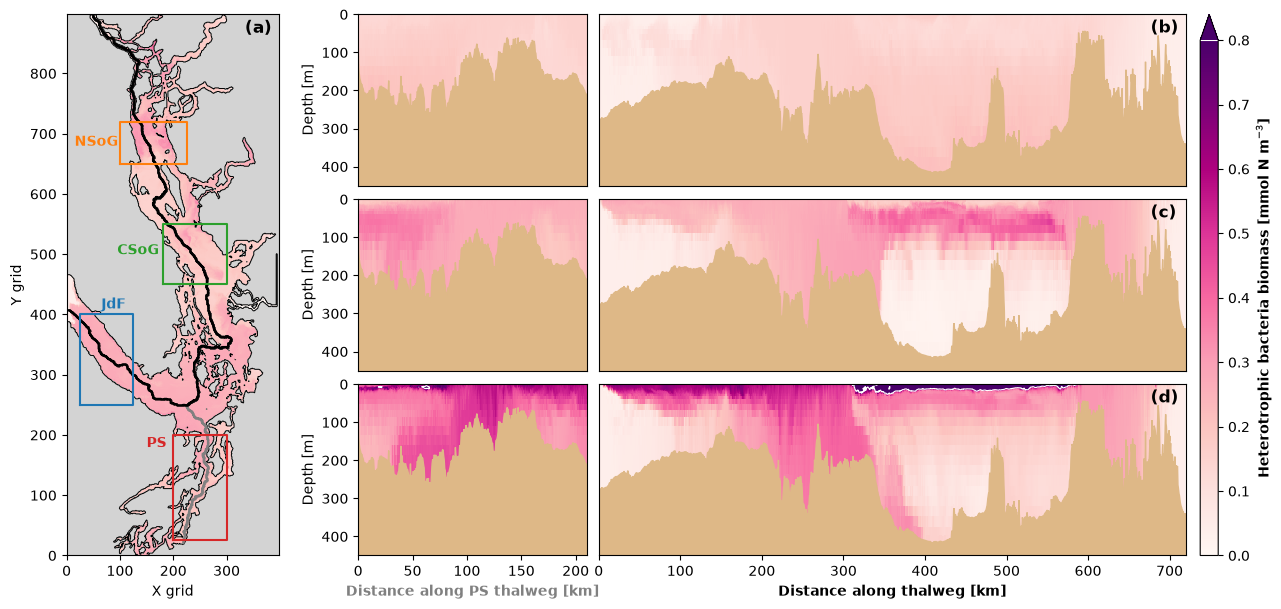

In [114]:
letters = ['(a)', '(b)', '(c)', '(d)']

axes[0].text(0.84, 0.99, letters[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[2].text(0.94, 0.97, letters[1], transform=axes[2].transAxes, fontsize=12, fontweight='bold', va='top')
axes[4].text(0.94, 0.97, letters[2], transform=axes[4].transAxes, fontsize=12, fontweight='bold', va='top')
axes[6].text(0.94, 0.97, letters[3], transform=axes[6].transAxes, fontsize=12, fontweight='bold', va='top')
fig

In [115]:
fig.savefig('Bacteria_thalwegs.pdf',bbox_inches='tight')